In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
import lightgbm as lgb
import optuna 
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df_raw = pd.read_csv("abalone.data.csv", sep = ',')

Preprocessing: dummies, drop diameter, new variables, drop outliers


In [3]:
df = df_raw
df

,gender,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [4]:
df = df[df['Height'] > 0]
df = df[df['Height'] < 0.3]
df[['Shucked weight', 'Viscera weight', 'Shell weight']] = df[['Shucked weight', 'Viscera weight', 'Shell weight']].div(df['Whole weight'], axis = 0)
df['weight_to_height'] = df['Whole weight'].div(df['Height'], axis = 0)
df['weight_to_length'] = df['Whole weight'].div(df['Length'], axis = 0)

sanity_check = df['Shucked weight'] + df['Viscera weight'] + df['Shell weight'] <= 1.02
df = df[sanity_check]
df = df.drop(index = df[df['weight_to_height'] > 77].index)
df = df.drop(columns = 'Diameter')
"""
df.loc[df['gender'] == 'I', 'gender'] = 1
df.loc[df['gender'] == 'M', 'gender'] = 2
df.loc[df['gender'] == 'F', 'gender'] = 3
"""
df


,gender,Length,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,weight_to_height,weight_to_length
0,M,0.455,0.095,0.5140,0.436770,0.196498,0.291829,15,5.410526,1.129670
1,M,0.350,0.090,0.2255,0.441242,0.215078,0.310421,7,2.505556,0.644286
2,F,0.530,0.135,0.6770,0.378877,0.209010,0.310192,9,5.014815,1.277358
3,M,0.440,0.125,0.5160,0.417636,0.220930,0.300388,10,4.128000,1.172727
4,I,0.330,0.080,0.2050,0.436585,0.192683,0.268293,7,2.562500,0.621212
...,...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.165,0.8870,0.417136,0.269448,0.280722,11,5.375758,1.569912
4173,M,0.590,0.135,0.9660,0.454451,0.222050,0.269669,10,7.155556,1.637288
4174,M,0.600,0.205,1.1760,0.446854,0.244473,0.261905,9,5.736585,1.960000
4175,F,0.625,0.150,1.0945,0.485153,0.238465,0.270443,10,7.296667,1.751200


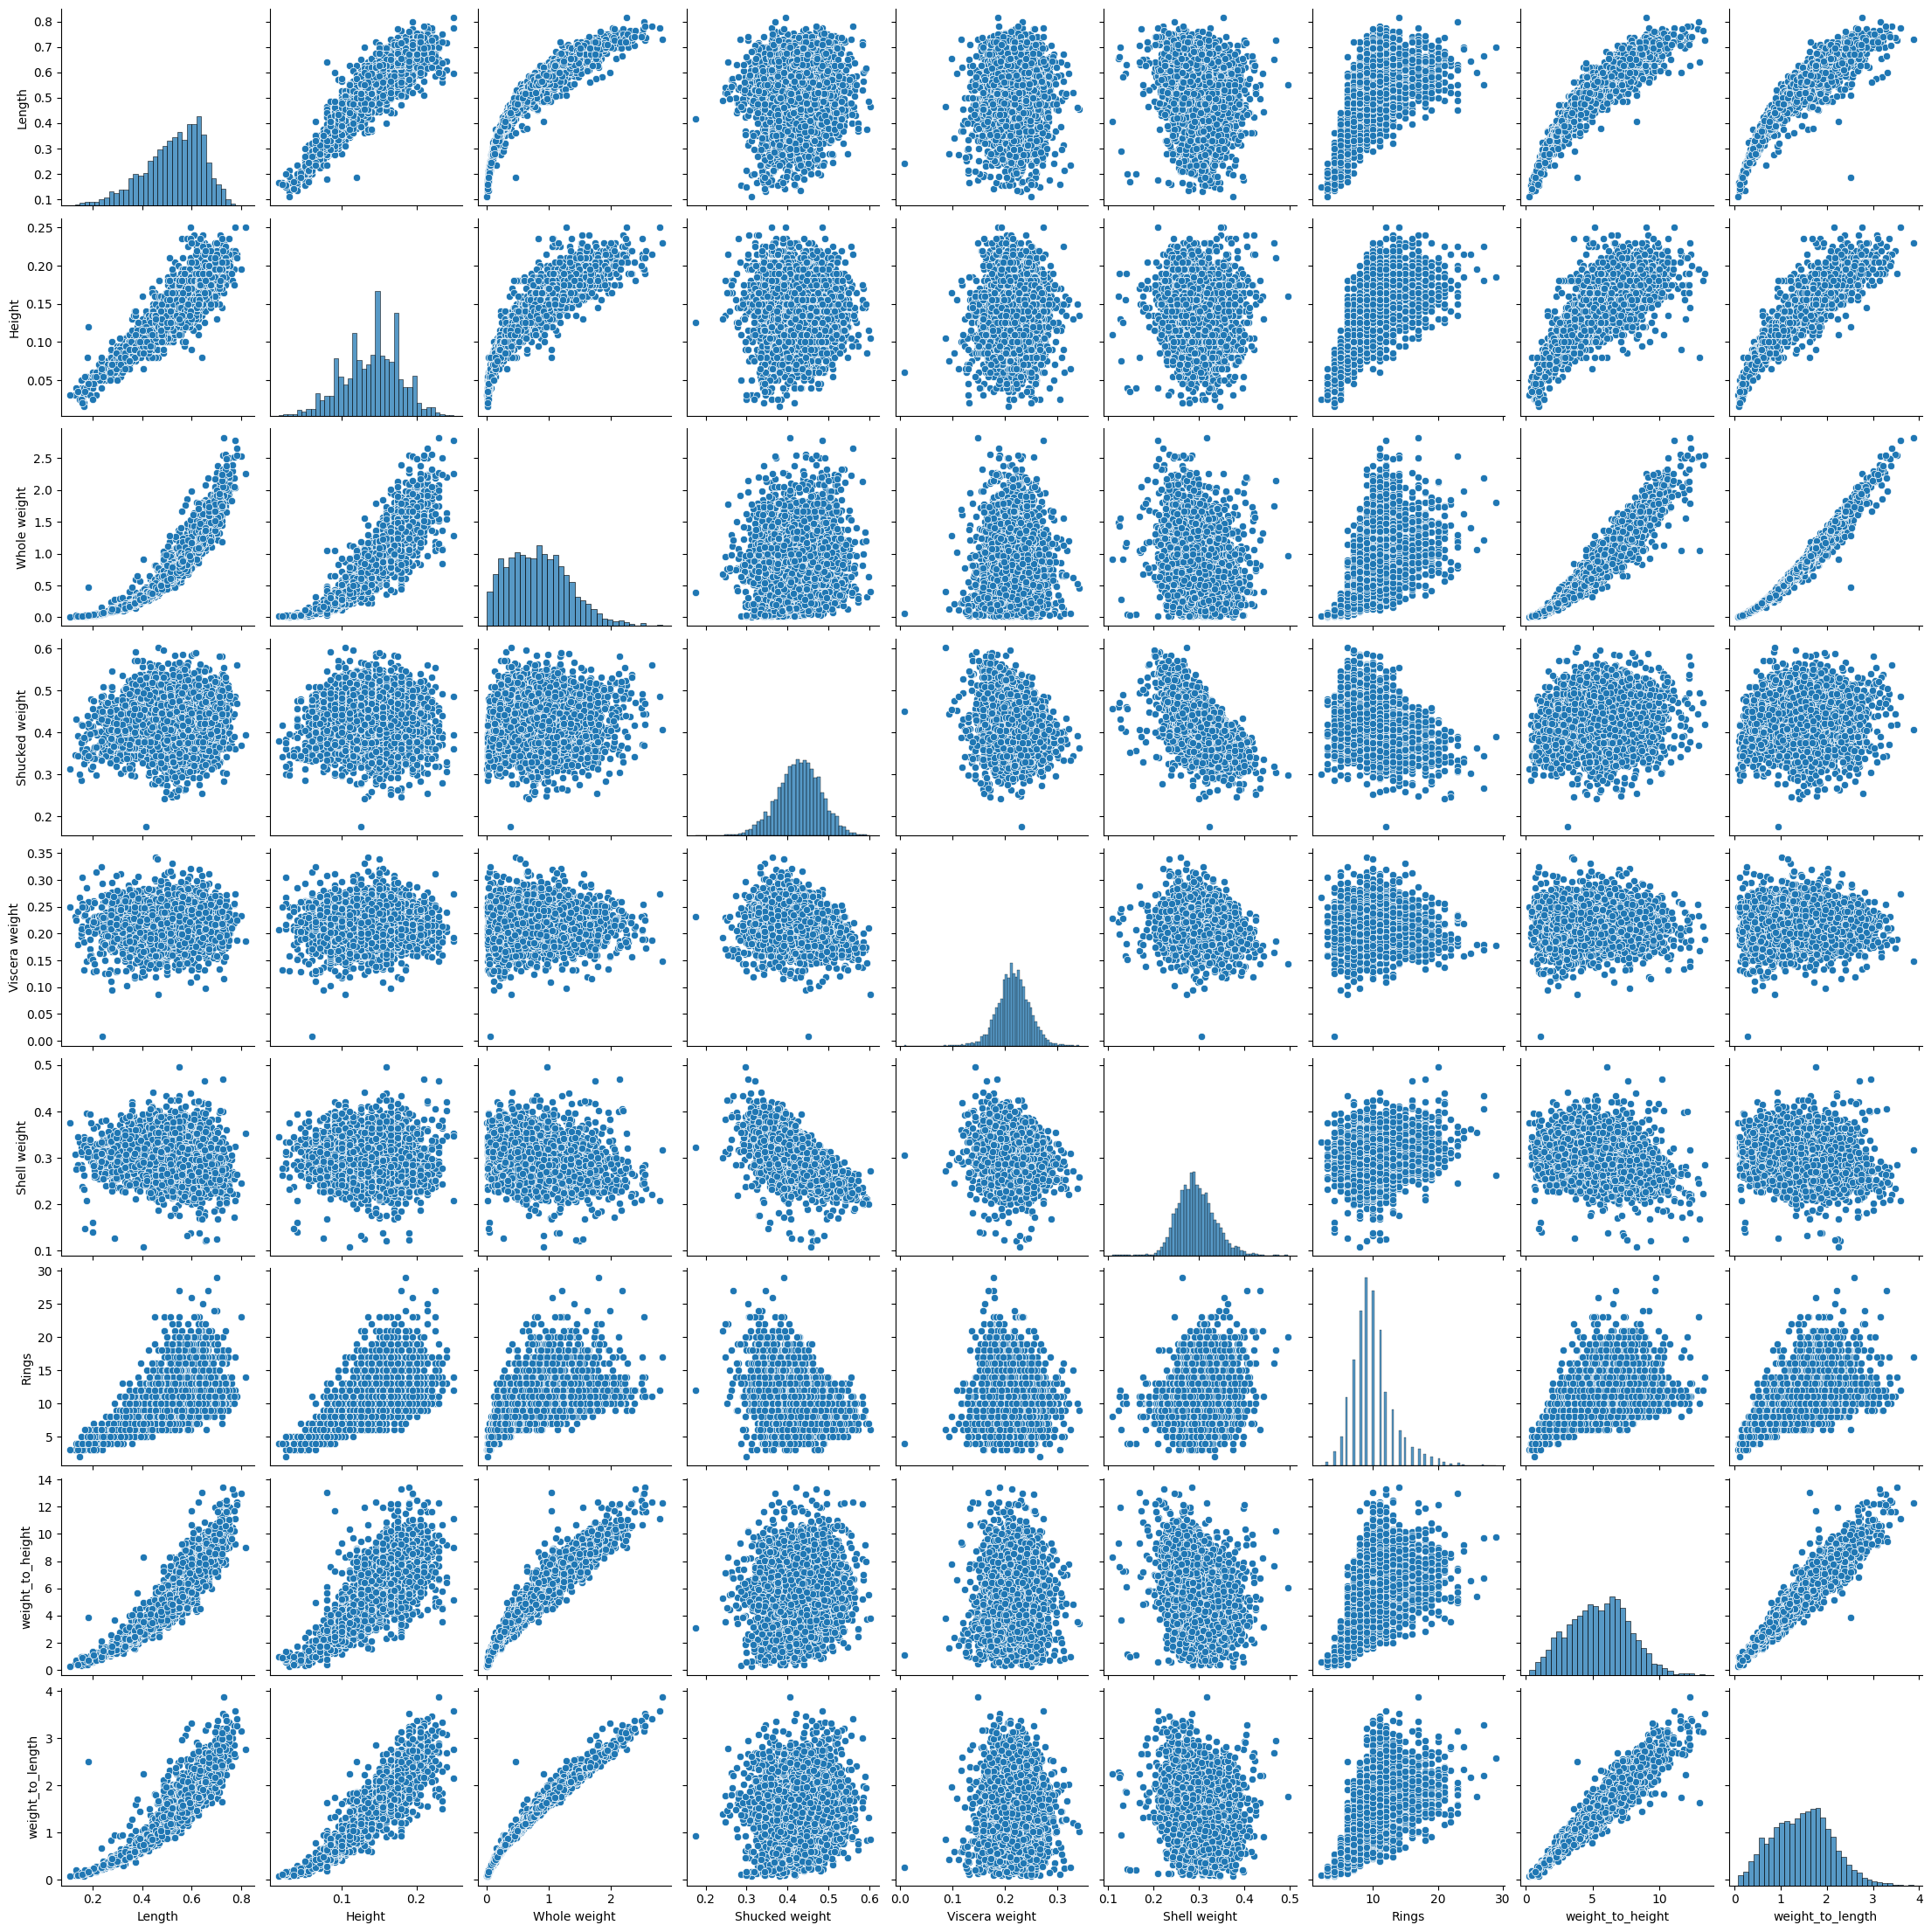

In [5]:
sns.pairplot(df)

Normalization to z-scores

In [6]:
z_scores = pd.DataFrame()
for col in [c for c in df.columns if c != 'gender']:

    z_scores[col] = (df[col] - df[col].mean()).div(df[col].std())

z_scores

,Length,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,weight_to_height,weight_to_length
0,-0.608758,-1.191258,-0.665386,0.152411,-0.671797,-0.035136,1.555292,-0.039424,-0.522465
1,-1.498832,-1.323393,-1.256804,0.236779,-0.056960,0.421284,-0.929997,-1.315136,-1.288942
2,0.027009,-0.134182,-0.331240,-0.939966,-0.257739,0.415656,-0.308675,-0.213200,-0.289249
3,-0.735911,-0.398451,-0.661286,-0.208641,0.136716,0.174971,0.001987,-0.602643,-0.454473
4,-1.668369,-1.587662,-1.298829,0.148919,-0.798048,-0.612914,-0.929997,-1.290129,-1.325378
...,...,...,...,...,...,...,...,...,...
4172,0.323700,0.658625,0.099256,-0.218061,1.742260,-0.307803,0.312648,-0.054693,0.172726
4173,0.535622,-0.134182,0.261204,0.486031,0.173762,-0.579134,0.001987,0.726902,0.279121
4174,0.620391,1.715702,0.691699,0.342672,0.915790,-0.769728,-0.308675,0.103764,0.788719
4175,0.832314,0.262222,0.524626,1.065338,0.716981,-0.560124,0.001987,0.788871,0.459001


In [13]:
X = z_scores.drop(columns = 'Rings')
y = z_scores['Rings']


In [14]:
n_components = np.arange(2, 16)
bics = []
sil_scores = []

pca = PCA(0.95)  # Keep 95% variance (~4-6 PCs)
X_pca = pca.fit_transform(X)

for n in n_components:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_pca)
    bics.append(gmm.bic(X_pca))
    labels = gmm.predict(X_pca)
    sil_scores.append(silhouette_score(X_pca, labels))

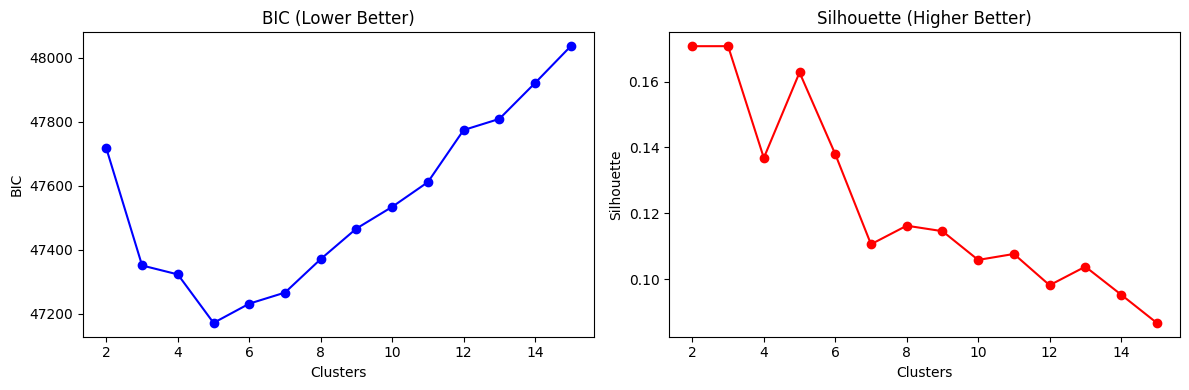

In [15]:
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.plot(n_components, bics, 'bo-')
plt.xlabel('Clusters')
plt.ylabel('BIC') 
plt.title('BIC (Lower Better)')

plt.subplot(122)
plt.plot(n_components, sil_scores, 'ro-')
plt.xlabel('Clusters')
plt.ylabel('Silhouette')
plt.title('Silhouette (Higher Better)')
plt.tight_layout(); plt.show()

Found k = 5(4 for dummies, always recheck with code) optimal clusters after reducing pca to 5 dimensions instead of 9

In [16]:
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X)
train_labels = gmm.predict(X)
print(f"Silhouette k=5: {silhouette_score(X, train_labels):.3f}")
print("Sizes:", np.bincount(train_labels))

Silhouette k=5: 0.144
Sizes: [1046  639  670 1211  500]


index=[f'Cluster {i}' for i in range(5)] by default, but 4 with dummy gender clustering

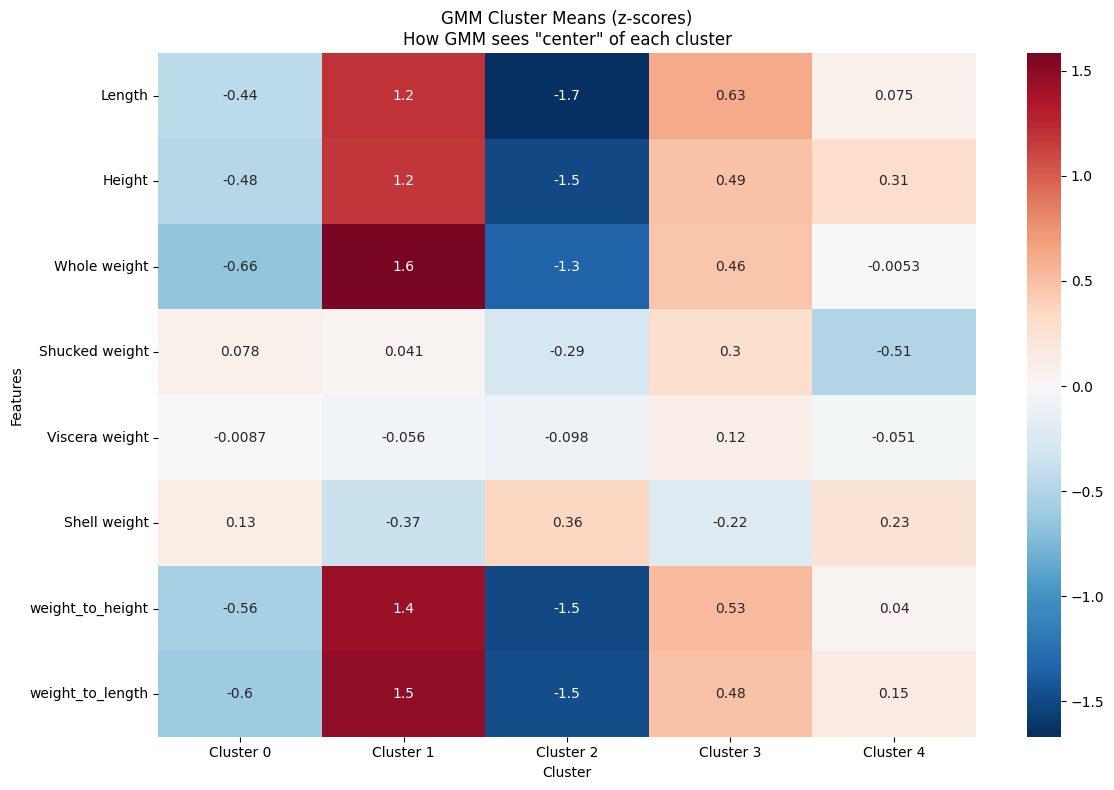

In [17]:
gmm_means = pd.DataFrame(gmm.means_, columns=X.columns, index=[f'Cluster {i}' for i in range(5)])
plt.figure(figsize=(12, 8))
sns.heatmap(gmm_means.T, annot=True, cmap='RdBu_r', center=0)
plt.title('GMM Cluster Means (z-scores)\nHow GMM sees "center" of each cluster')
plt.xlabel('Cluster')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

all ranges are 5 by default, but 4 with dummies!!!

Cluster Summary:
            Cluster 0  Cluster 1  Cluster 2  Cluster 3  Cluster 4
Size          1046.00     639.00     670.00     1211.0     500.00
Mean_Rings      -0.28       0.69      -0.99        0.2       0.56


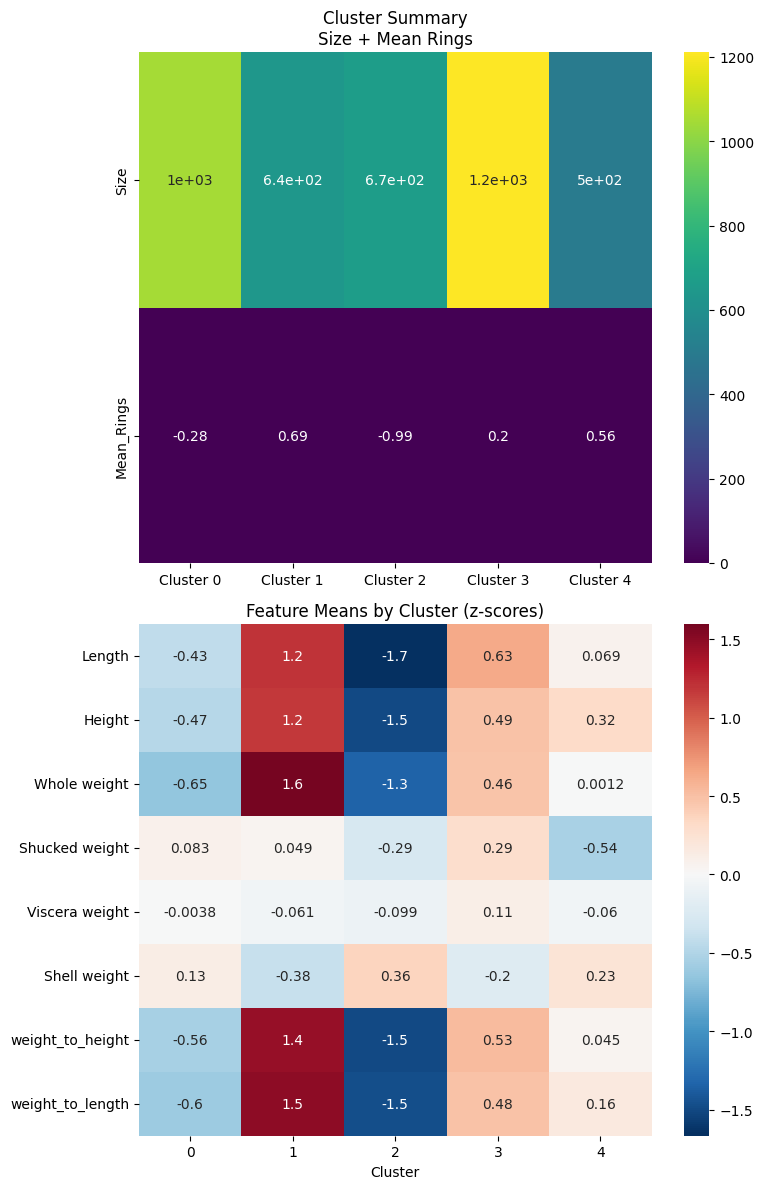

In [18]:
cluster_sizes = pd.Series(train_labels).value_counts().sort_index()

mean_rings = []
for i in range(5):
    mask = train_labels == i
    mean_rings.append(y[mask].mean())  # Direct boolean on y_train!

cluster_summary = pd.DataFrame({
    'Size': cluster_sizes.values,
    'Mean_Rings': mean_rings
}, index=[f'Cluster {i}' for i in range(5)]).T

print("Cluster Summary:")
print(cluster_summary.round(2))

# Features heatmap (unchanged, safe)
cluster_features = X.copy()
cluster_features['Cluster'] = train_labels
means_all = cluster_features.groupby('Cluster').mean(numeric_only = True).T

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 12))

sns.heatmap(cluster_summary, annot=True, cmap='viridis', ax=ax1)
ax1.set_title('Cluster Summary\nSize + Mean Rings')

sns.heatmap(means_all, annot=True, cmap='RdBu_r', center=0, ax=ax2)  # Skip Cluster row
ax2.set_title('Feature Means by Cluster (z-scores)')

plt.tight_layout()
plt.show()

In [20]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Cluster': train_labels,
    'gender': X['gender'],  # Optional overlay
    'Rings': y
})


KeyError: 'gender'

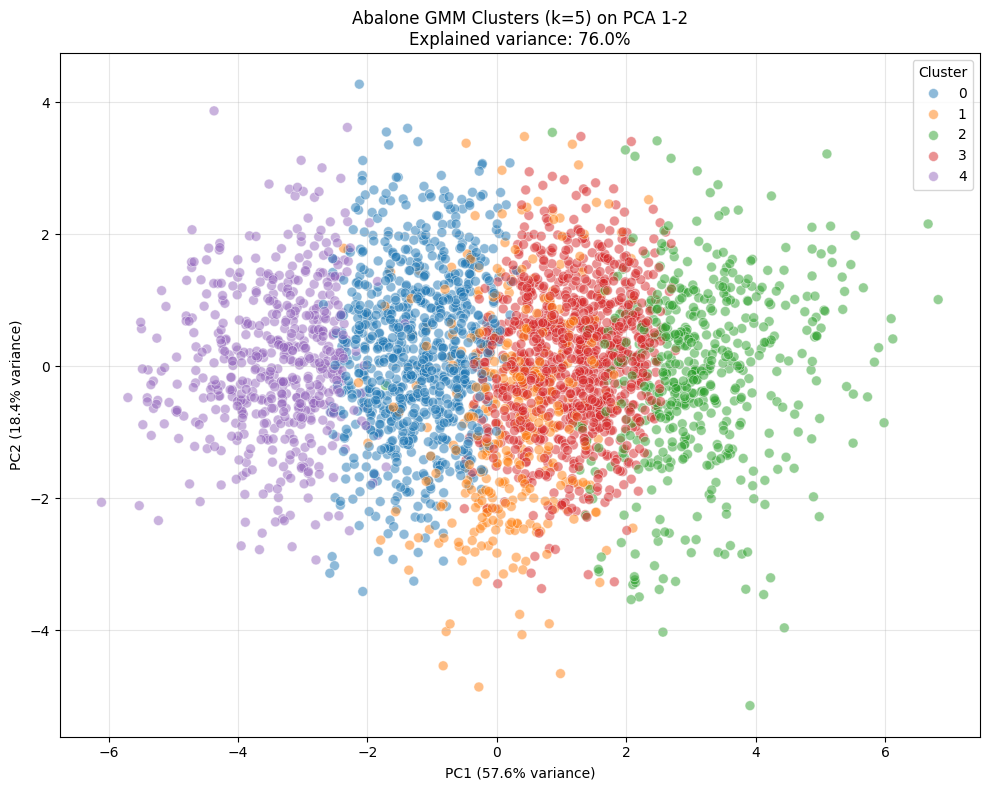

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='tab10', s=50, alpha = 0.5)
plt.title('Abalone GMM Clusters (k=5) on PCA 1-2\nExplained variance: {:.1%}'.format(sum(pca.explained_variance_ratio_)))
plt.xlabel('PC1 ({:.1%} variance)'.format(pca.explained_variance_ratio_[0]))
plt.ylabel('PC2 ({:.1%} variance)'.format(pca.explained_variance_ratio_[1]))
plt.legend(title='Cluster')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df['Cluster'] = train_labels
df

,Length,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,gender_F,gender_I,gender_M,weight_to_height,weight_to_length,Cluster
0,0.455,0.095,0.5140,0.436770,0.196498,0.291829,15,False,False,True,5.410526,1.129670,1
1,0.350,0.090,0.2255,0.441242,0.215078,0.310421,7,False,False,True,2.505556,0.644286,2
2,0.530,0.135,0.6770,0.378877,0.209010,0.310192,9,True,False,False,5.014815,1.277358,3
3,0.440,0.125,0.5160,0.417636,0.220930,0.300388,10,False,False,True,4.128000,1.172727,2
4,0.330,0.080,0.2050,0.436585,0.192683,0.268293,7,False,True,False,2.562500,0.621212,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4172,0.565,0.165,0.8870,0.417136,0.269448,0.280722,11,True,False,False,5.375758,1.569912,3
4173,0.590,0.135,0.9660,0.454451,0.222050,0.269669,10,False,False,True,7.155556,1.637288,1
4174,0.600,0.205,1.1760,0.446854,0.244473,0.261905,9,False,False,True,5.736585,1.960000,1
4175,0.625,0.150,1.0945,0.485153,0.238465,0.270443,10,True,False,False,7.296667,1.751200,3


In [ ]:
df.loc[df['gender'] == 1, 'gender'] = 'I'
df.loc[df['gender'] == 2, 'gender'] = 'M'
df.loc[df['gender'] == 3, 'gender'] = 'F'
df

,gender,Length,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,weight_to_height,weight_to_length,Cluster
0,M,0.455,0.095,0.5140,0.436770,0.196498,0.291829,15,5.410526,1.129670,4
1,M,0.350,0.090,0.2255,0.441242,0.215078,0.310421,7,2.505556,0.644286,2
2,F,0.530,0.135,0.6770,0.378877,0.209010,0.310192,9,5.014815,1.277358,0
3,M,0.440,0.125,0.5160,0.417636,0.220930,0.300388,10,4.128000,1.172727,0
4,I,0.330,0.080,0.2050,0.436585,0.192683,0.268293,7,2.562500,0.621212,2
...,...,...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.165,0.8870,0.417136,0.269448,0.280722,11,5.375758,1.569912,3
4173,M,0.590,0.135,0.9660,0.454451,0.222050,0.269669,10,7.155556,1.637288,3
4174,M,0.600,0.205,1.1760,0.446854,0.244473,0.261905,9,5.736585,1.960000,4
4175,F,0.625,0.150,1.0945,0.485153,0.238465,0.270443,10,7.296667,1.751200,3


In [ ]:
df = pd.get_dummies(df)
df

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,gender_F,gender_I,gender_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15,False,False,True
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7,False,False,True
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9,True,False,False
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10,False,False,True
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
4172,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11,True,False,False
4173,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10,False,False,True
4174,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9,False,False,True
4175,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10,True,False,False


In [ ]:
X = df.drop(columns = 'Rings')
y = df['Rings']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

Watch the range!!

In [ ]:
study = []
best_params = []
lgb_models = []
y_pred = []
rmse = []
r2 = []
scaler = StandardScaler()

for cluster in range(5):

    train_mask = X_train['Cluster'] == cluster
    test_mask = X_test['Cluster'] == cluster

    X_train_local = X_train[train_mask]
    y_train_local = y_train[train_mask]
    X_test_local = X_test[test_mask]
    y_test_local = y_test[test_mask]
    
    X_train_local = X_train_local.drop(columns = 'Cluster')
    X_test_local = X_test_local.drop(columns = 'Cluster')

    X_train_local = scaler.fit_transform(X_train_local)
    X_test_local = scaler.transform(X_test_local)

    study.append(optuna.create_study(direction='maximize'))
    study[cluster].optimize(objective, n_trials=50, show_progress_bar=True)

    print("Best R² on ", cluster, "th cluster validation:", study[cluster].best_value)
    print("Best ", cluster, "th cluster params:", study[cluster].best_params)

    best_params.append(study[cluster].best_params)

    best_params[cluster].update({
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'random_state': 42,
    'verbose': -1
    })

    lgb_models.append(lgb.LGBMRegressor(
    n_estimators=1000,
    **best_params[cluster]
    ))

    lgb_models[cluster].fit(
    X_train_local, y_train_local,
    eval_set=[(X_test_local, y_test_local)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
    )

    y_pred.append(lgb_models[cluster].predict(X_test_local))
    rmse.append(root_mean_squared_error(y_test_local, y_pred[cluster]))
    r2.append(r2_score(y_test_local, y_pred[cluster]))
    print(f"{cluster}th cluster's RMSE: {rmse[cluster]:.4f}, R²: {r2[cluster]:.4f}")

def objective(trial):
    # Hyperparameter search space
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
        'random_state': 42,
        'verbose': -1
    }

    # Train/validation on your existing split
    model_inner = lgb.LGBMRegressor(
        n_estimators=1000,
        **params
    )
    model_inner.fit(
        X_train_local, y_train_local,
        eval_set=[(X_test_local, y_test_local)],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    y_predf = model_inner.predict(X_test_local, num_iteration=model_inner.best_iteration_)
    return r2_score(y_test_local, y_predf)  # maximize R² on raw Ring




[I 2026-01-25 00:57:53,248] A new study created in memory with name: no-name-eea034bd-0b2a-4db7-8f50-d1631c2ed6af


  0%|          | 0/50 [00:00<?, ?it/s]

c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserW

[I 2026-01-25 00:57:53,293] Trial 0 finished with value: 0.6122600466811151 and parameters: {'num_leaves': 112, 'learning_rate': 0.14706050134131654, 'feature_fraction': 0.7652657395579893, 'bagging_fraction': 0.8262579719987071, 'bagging_freq': 6, 'min_child_samples': 26, 'reg_alpha': 4.757729083500649, 'reg_lambda': 2.0637852525279383}. Best is trial 0 with value: 0.6122600466811151.
[I 2026-01-25 00:57:53,390] Trial 1 finished with value: 0.6136497423685976 and parameters: {'num_leaves': 87, 'learning_rate': 0.013766529981497584, 'feature_fraction': 0.904405776518548, 'bagging_fraction': 0.9526209528930386, 'bagging_freq': 7, 'min_child_samples': 66, 'reg_alpha': 3.7673397180299557, 'reg_lambda': 4.561898792752231}. Best is trial 1 with value: 0.6136497423685976.
[I 2026-01-25 00:57:53,416] Trial 2 finished with value: 0.6047579179440787 and parameters: {'num_leaves': 111, 'learning_rate': 0.1441894137101989, 'feature_fraction': 0.8482947823093336, 'bagging_fraction': 0.677311622834

c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[I 2026-01-25 00:58:04,937] Trial 43 finished with value: 0.3939825231764975 and parameters: {'num_leaves': 128, 'learning_rate': 0.048683386552674096, 'feature_fraction': 0.8934360115219379, 'bagging_fraction': 0.6423406059983132, 'bagging_freq': 3, 'min_child_samples': 86, 'reg_alpha': 1.7682150552524905, 'reg_lambda': 4.529696802218797}. Best is trial 29 with value: 0.4003317469794271.
[I 2026-01-25 00:58:04,978] Trial 44 finished with value: 0.38617133612654686 and parameters: {'num_leaves': 121, 'learning_rate': 0.0582274538635131, 'feature_fraction': 0.9345853661855874, 'bagging_fraction': 0.6166837404051533, 'bagging_freq': 2, 'min_child_samples': 95, 'reg_alpha': 1.5152866216348402, 'reg_lambda': 4.775042958580668}. Best is trial 29 with value: 0.4003317469794271.
[I 2026-01-25 00:58:05,019] Trial 45 finished with value: 0.36628908236237756 and parameters: {'num_leaves': 114, 'learning_rate': 0.08117468738563532, 'feature_fraction': 0.8801418534588813, 'bagging_fraction': 0.961

c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[I 2026-01-25 00:58:05,157] Trial 47 finished with value: 0.3663509750126076 and parameters: {'num_leaves': 142, 'learning_rate': 0.035775335456511126, 'feature_fraction': 0.9794384234062348, 'bagging_fraction': 0.6046774555839975, 'bagging_freq': 3, 'min_child_samples': 28, 'reg_alpha': 3.0637441425235767, 'reg_lambda': 4.346549490666087}. Best is trial 29 with value: 0.4003317469794271.
[I 2026-01-25 00:58:05,206] Trial 48 finished with value: 0.38900730780931037 and parameters: {'num_leaves': 132, 'learning_rate': 0.16263964751265175, 'feature_fraction': 0.9114268777967909, 'bagging_fraction': 0.6672682567747611, 'bagging_freq': 7, 'min_child_samples': 97, 'reg_alpha': 2.4606385195015985, 'reg_lambda': 1.7367490904626814}. Best is trial 29 with value: 0.4003317469794271.
[I 2026-01-25 00:58:05,256] Trial 49 finished with value: 0.3884763703084365 and parameters: {'num_leaves': 124, 'learning_rate': 0.04534502873731628, 'feature_fraction': 0.943964780711591, 'bagging_fraction': 0.644

c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
rmse

[1.6557652168665096,
 2.466759969860695,
 1.2040549601754647,
 1.9609271858540447,
 2.570202483586729]

Watch the range!!!

In [ ]:
test_sizes = [sum(X_test['Cluster'] == c) for c in range(5)]
total_test = sum(test_sizes)

weighted_rmse = sum(rmse[i] * test_sizes[i] / total_test for i in range(5))
weighted_r2 = sum(r2[i] * test_sizes[i] / total_test for i in range(5))

print(f"Overall Weighted RMSE: {weighted_rmse:.4f}")
print(f"Overall Weighted R²:   {weighted_r2:.4f}")

Overall Weighted RMSE: 1.9568
Overall Weighted R²:   0.5193


Overall Weighted RMSE: 1.9036
Overall Weighted R²:   0.4635

Overall Weighted RMSE: 1.9568
Overall Weighted R²:   0.5193 after gender dummy clusters


Now cluster is an ordinal variable

[I 2026-01-25 01:01:18,606] A new study created in memory with name: no-name-8af6bcac-2456-418c-ba2b-b83b7a9b19bf


  0%|          | 0/50 [00:00<?, ?it/s]

c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[I 2026-01-25 01:01:18,667] Trial 0 finished with value: 0.6086563547373032 and parameters: {'num_leaves': 127, 'learning_rate': 0.1227832420210097, 'feature_fraction': 0.8039050935375184, 'bagging_fraction': 0.6473997998279991, 'bagging_freq': 3, 'min_child_samples': 34, 'reg_alpha': 3.619799592531432, 'reg_lambda': 0.7295060091677347}. Best is trial 0 with value: 0.6086563547373032.
[I 2026-01-25 01:01:18,799] Trial 1 finished with value: 0.5979706826129318 and parameters: {'num_leaves': 138, 'learning_rate': 0.1409978374702003, 'feature_fraction': 0.7018564647323033, 'bagging_fraction': 0.9259016953695085, 'bagging_freq': 5, 'min_child_samples': 11, 'reg_alpha': 2.572658213302901, 'reg_lambda': 0.6527626288658217}. Best is trial 0 with value: 0.6086563547373032.


c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

[I 2026-01-25 01:01:24,285] Trial 43 finished with value: 0.6197383724416212 and parameters: {'num_leaves': 38, 'learning_rate': 0.06471912529652143, 'feature_fraction': 0.9786298398392134, 'bagging_fraction': 0.927453458651371, 'bagging_freq': 7, 'min_child_samples': 64, 'reg_alpha': 1.673289113003498, 'reg_lambda': 1.98377846956277}. Best is trial 22 with value: 0.6230144266887709.
[I 2026-01-25 01:01:24,390] Trial 44 finished with value: 0.6188920960240618 and parameters: {'num_leaves': 28, 'learning_rate': 0.03513504004238254, 'feature_fraction': 0.9234200107528991, 'bagging_fraction': 0.9140247390896565, 'bagging_freq': 6, 'min_child_samples': 53, 'reg_alpha': 0.6034785211799187, 'reg_lambda': 3.9488909686461104}. Best is trial 22 with value: 0.6230144266887709.
[I 2026-01-25 01:01:24,459] Trial 45 finished with value: 0.6204939767886509 and parameters: {'num_leaves': 42, 'learning_rate': 0.13263847926117414, 'feature_fraction': 0.9508993441516659, 'bagging_fraction': 0.8760536301

c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[I 2026-01-25 01:01:24,516] Trial 46 finished with value: 0.617941278359951 and parameters: {'num_leaves': 35, 'learning_rate': 0.1973907369390083, 'feature_fraction': 0.9883022588538721, 'bagging_fraction': 0.9804670778464097, 'bagging_freq': 6, 'min_child_samples': 15, 'reg_alpha': 0.9378176449577115, 'reg_lambda': 4.709459690127111}. Best is trial 22 with value: 0.6230144266887709.
[I 2026-01-25 01:01:24,614] Trial 47 finished with value: 0.6142997723800696 and parameters: {'num_leaves': 120, 'learning_rate': 0.028822850811022246, 'feature_fraction': 0.781638052420806, 'bagging_fraction': 0.8516020521591864, 'bagging_freq': 7, 'min_child_samples': 69, 'reg_alpha': 1.5306987851926661, 'reg_lambda': 4.375762380387671}. Best is trial 22 with value: 0.6230144266887709.


c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\4infi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[I 2026-01-25 01:01:24,698] Trial 48 finished with value: 0.6172494694247219 and parameters: {'num_leaves': 20, 'learning_rate': 0.03123100301901098, 'feature_fraction': 0.6188361206288573, 'bagging_fraction': 0.7792267818844092, 'bagging_freq': 5, 'min_child_samples': 47, 'reg_alpha': 3.891317517415827, 'reg_lambda': 3.5819052951253774}. Best is trial 22 with value: 0.6230144266887709.
[I 2026-01-25 01:01:24,757] Trial 49 finished with value: 0.6171074254978033 and parameters: {'num_leaves': 96, 'learning_rate': 0.1083926620416324, 'feature_fraction': 0.9975490753935015, 'bagging_fraction': 0.8930867363808103, 'bagging_freq': 6, 'min_child_samples': 89, 'reg_alpha': 0.49892277502577237, 'reg_lambda': 3.0444682116167976}. Best is trial 22 with value: 0.6230144266887709.
Best R² on validation: 0.6230144266887709
Best params: {'num_leaves': 33, 'learning_rate': 0.02224388778189915, 'feature_fraction': 0.9612448194077726, 'bagging_fraction': 0.9112248536016335, 'bagging_freq': 6, 'min_chi

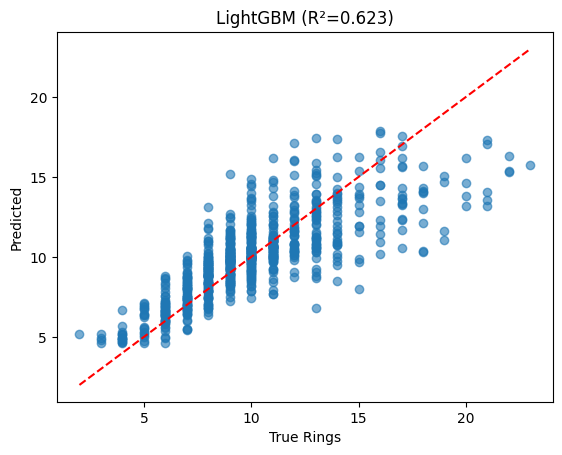

In [ ]:
X_train_local = scaler.fit_transform(X_train)
X_test_local = scaler.transform(X_test)

y_train_local = y_train
y_test_local = y_test

study1 = optuna.create_study(direction='maximize')
study1.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best R² on validation:", study1.best_value)
print("Best params:", study1.best_params)

best_params1 = study1.best_params

best_params1.update({
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'random_state': 42,
    'verbose': -1
})

lgb_model1 = lgb.LGBMRegressor(
    n_estimators=1000,
    **best_params1
)

lgb_model1.fit(
    X_train_local, y_train_local,
    eval_set=[(X_test_local, y_test_local)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

y_pred1 = lgb_model1.predict(X_test_local)
rmse1 = root_mean_squared_error(y_test_local, y_pred1)
r21 = r2_score(y_test_local, y_pred1)
print(f"RMSE: {rmse1:.4f}, R²: {r21:.4f}")

# Plot predictions
plt.scatter(y_test_local, y_pred1, alpha=0.6)
plt.plot([y_test_local.min(), y_test_local.max()], [y_test_local.min(), y_test_local.max()], 'r--')
plt.xlabel('True Rings'); plt.ylabel('Predicted')
plt.title(f'LightGBM (R²={r21:.3f})')
plt.show()

RMSE: 1.9906, R²: 0.6225 for ordinal, same for factor, does not change when clustering genders as dummies

In [ ]:
X_train = pd.get_dummies(X_train, columns=['Cluster'], prefix='cluster', drop_first=False)
X_test = pd.get_dummies(X_test, columns=['Cluster'], prefix='cluster', drop_first=False)

They did not lie when they said dummy genders were a bit worse